In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [3]:
train_info = pd.read_csv("train_info.csv")
test_info = pd.read_csv("test_info.csv")
test_answer = pd.read_csv("test_answer.csv")

In [4]:
def chenge(x):
    return [int(i) for i in str(x).replace('[','').replace(']','').split() if i.strip() != '']

In [5]:
train_info['cut_point'] = train_info['cut_point'].apply(chenge)
test_info['cut_point'] = test_info['cut_point'].apply(chenge)

In [6]:
def get_feat(file_name, cut_point):
    df = pd.read_csv(file_name, header=None, sep=r'\s+', names=['Ax','Ay','Az','Gx','Gy','Gz'])
    df = df.apply(pd.to_numeric, errors='coerce').dropna()

    old = 0
    all = []

    for now in cut_point:
        part = df.iloc[old:now]
        old = now
        if len(part) == 0:
            continue
            
        mean = part.mean()
        s = part.std()
        one = pd.concat([mean, s]).values
        all.append(one)

    if len(all) == 0:
        return np.zeros(12)

    all = np.stack(all)
    ans = np.concatenate([all.mean(axis=0), all.max(axis=0)], axis=0)
    return ans

In [7]:
tr_feat = []
tr_lab = []

In [8]:
for _, row in train_info.iterrows():
    file_name = f"train_data/{row['unique_id']}.txt"
    feat = get_feat(file_name, row['cut_point'])
    tr_feat.append(feat)

    lab = [
        row['play years'],
        row['hold racket handed'] - 1,
        row['level'] - 2,
        row['gender'] - 1
    ]
    tr_lab.append(lab)


In [9]:
x_tr = torch.tensor(np.stack(tr_feat), dtype=torch.float32)
y_tr = torch.tensor(np.stack(tr_lab), dtype=torch.long)

In [10]:
te_feat = []
for _, row in test_info.iterrows():
    file_name = f"test_data/{row['unique_id']}.txt"
    feat = get_feat(file_name, row['cut_point'])
    te_feat.append(feat)


In [11]:
x_te = torch.tensor(np.stack(te_feat), dtype=torch.float32)

In [12]:
class MyNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 64)

        self.out_year = nn.Linear(64, 3)
        self.out_hand = nn.Linear(64, 2)
        self.out_lvl = nn.Linear(64, 4)
        self.out_gen = nn.Linear(64, 2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return {
            'year': self.out_year(x),
            'hand': self.out_hand(x),
            'level': self.out_lvl(x),
            'gender': self.out_gen(x)
        }

in_dim = x_tr.shape[1]
net = MyNet(in_dim)
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
ce = nn.CrossEntropyLoss()

In [13]:
for ep in range(100):
    opt.zero_grad()
    out = net(x_tr)

    loss = (
        ce(out['year'], y_tr[:,0]) +
        ce(out['hand'], y_tr[:,1]) +
        ce(out['level'], y_tr[:,2]) +
        ce(out['gender'], y_tr[:,3])
    )
    loss.backward()
    opt.step()


In [14]:
net.eval()
with torch.no_grad():
    out_te = net(x_te)

p_year = torch.argmax(out_te['year'], dim=1).numpy()
p_hand = torch.argmax(out_te['hand'], dim=1).numpy() + 1
p_lvl = torch.argmax(out_te['level'], dim=1).numpy() + 2
p_gen = torch.argmax(out_te['gender'], dim=1).numpy() + 1

te_res = test_info[['unique_id', 'mode']].copy()
te_res['play years'] = p_year
te_res['hold racket handed'] = p_hand
te_res['level'] = p_lvl
te_res['gender'] = p_gen

te_res.to_csv("predicted_test.csv", index=False)


In [15]:
net.eval()
with torch.no_grad():
    out_tr = net(x_tr)

p_year2 = torch.argmax(out_tr['year'], dim=1).numpy()
p_hand2 = torch.argmax(out_tr['hand'], dim=1).numpy()
p_lvl2 = torch.argmax(out_tr['level'], dim=1).numpy()
p_gen2 = torch.argmax(out_tr['gender'], dim=1).numpy()

t_year = y_tr[:,0].numpy()
t_hand = y_tr[:,1].numpy()
t_lvl = y_tr[:,2].numpy()
t_gen = y_tr[:,3].numpy()


In [23]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,auc

print("year_acc:", accuracy_score(t_year, p_year2))
print("year_f1:", f1_score(t_year, p_year2, average='macro'))

print("hand_acc:", accuracy_score(t_hand, p_hand2))
print("hand_f1:", f1_score(t_hand, p_hand2, average='macro'))

print("level_acc:", accuracy_score(t_lvl, p_lvl2))
print("level_f1:", f1_score(t_lvl, p_lvl2, average='macro'))

print("gender_acc:", accuracy_score(t_gen, p_gen2))
print("gender_f1:", f1_score(t_gen, p_gen2, average='macro'))


year_acc: 0.7442455242966752
year_f1: 0.7208450187296425
hand_acc: 0.9943734015345268
hand_f1: 0.9907459563852901
level_acc: 0.7953964194373402
level_f1: 0.7070110535430046
gender_acc: 0.9258312020460358
gender_f1: 0.862992611581456


In [24]:
net.eval()
with torch.no_grad():
    out_te2 = net(x_te)

p_year3 = torch.argmax(out_te2['year'], dim=1).numpy()
p_hand3 = torch.argmax(out_te2['hand'], dim=1).numpy()
p_lvl3 = torch.argmax(out_te2['level'], dim=1).numpy()
p_gen3 = torch.argmax(out_te2['gender'], dim=1).numpy()

try:
    t_ans = pd.read_csv("test_answer.csv")
    t_year2 = t_ans['play years'].values
    t_hand2 = t_ans['hold racket handed'].values - 1
    t_lvl2 = t_ans['level'].values - 2
    t_gen2 = t_ans['gender'].values - 1

    print("year_acc:", accuracy_score(t_year2, p_year3))
    print("year_f1:", f1_score(t_year2, p_year3, average='macro'))

    print("hand_acc:", accuracy_score(t_hand2, p_hand3))
    print("hand_f1:", f1_score(t_hand2, p_hand3, average='macro'))

    print("level_acc:", accuracy_score(t_lvl2, p_lvl3))
    print("level_f1:", f1_score(t_lvl2, p_lvl3, average='macro'))

    print("gender_acc:", accuracy_score(t_gen2, p_gen3))
    print("gender_f1:", f1_score(t_gen2, p_gen3, average='macro'))

    auc_hand = roc_auc_score(t_hand2, torch.softmax(out_te2['hand'], dim=1)[:,1].numpy())
    auc_gen = roc_auc_score(t_gen2, torch.softmax(out_te2['gender'], dim=1)[:,1].numpy())

    print("hand_auc:", auc_hand)
    print("gender_auc:", auc_gen)

except FileNotFoundError:
    print("no!!!")

year_acc: 0.37202797202797205
year_f1: 0.3176266436706792
hand_acc: 0.9762237762237762
hand_f1: 0.9545078577336642
level_acc: 0.4188811188811189
level_f1: 0.3019402724802551
gender_acc: 0.7678321678321678
gender_f1: 0.5557826108110738
hand_auc: 0.9726169229361157
gender_auc: 0.6303738252697528


year acc: 0.7442455242966752
year f1 : 0.7448172286704415
hand acc: 0.9943734015345268
hand f1 : 0.9943704379355487
level acc: 0.7953964194373402
level f1 : 0.7950971817226052
gender acc: 0.9258312020460358
gender f1 : 0.9246446727698919


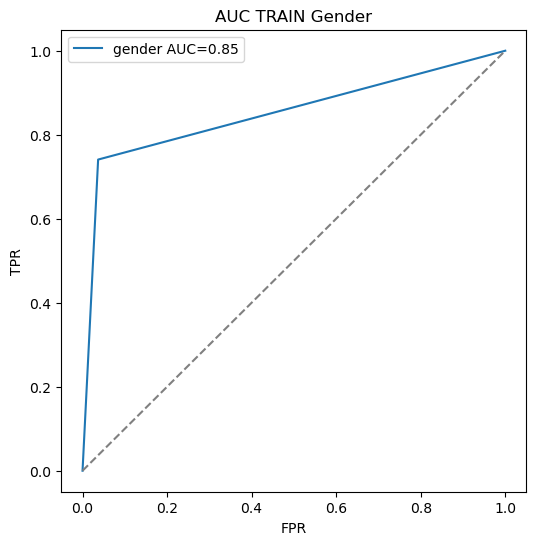

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

merged_tr = pd.DataFrame({
    "year_true": t_year,
    "year_pred": p_year2,
    "hand_true": t_hand,
    "hand_pred": p_hand2,
    "level_true": t_lvl,
    "level_pred": p_lvl2,
    "gender_true": t_gen,
    "gender_pred": p_gen2
})

cols = ["year", "hand", "level", "gender"]

for c in cols:
    print(c, "acc:", accuracy_score(merged_tr[f"{c}_true"], merged_tr[f"{c}_pred"]))
    print(c, "f1 :", f1_score(merged_tr[f"{c}_true"], merged_tr[f"{c}_pred"],average='weighted',labels=list(np.unique(merged_tr[f"{c}_true"]))))

fpr, tpr, _ = roc_curve(merged_tr["gender_true"], merged_tr["gender_pred"])
roc_val = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"gender AUC={roc_val:.2f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("AUC TRAIN Gender")
plt.legend()
plt.show()

year acc: 0.37202797202797205
year f1 : 0.32533496744502416
hand acc: 0.9762237762237762
hand f1 : 0.9764435729696276
level acc: 0.4188811188811189
level f1 : 0.3619603352459068
gender acc: 0.7678321678321678
gender f1 : 0.723190155827727


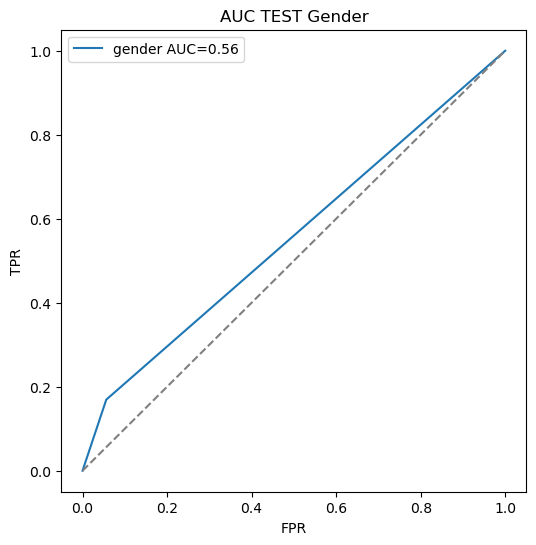

In [32]:
merged_te = pd.DataFrame({
    "year_true": t_year2,
    "year_pred": p_year3,
    "hand_true": t_hand2,
    "hand_pred": p_hand3,
    "level_true": t_lvl2,
    "level_pred": p_lvl3,
    "gender_true": t_gen2,
    "gender_pred": p_gen3
})

for c in cols:
    print(c, "acc:", accuracy_score(merged_te[f"{c}_true"], merged_te[f"{c}_pred"]))
    print(c, "f1 :", f1_score(merged_te[f"{c}_true"], merged_te[f"{c}_pred"],average='weighted',labels=list(np.unique(merged_te[f"{c}_true"]))))

fpr, tpr, _ = roc_curve(merged_te["gender_true"], merged_te["gender_pred"])
roc_val = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"gender AUC={roc_val:.2f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("AUC TEST Gender")
plt.legend()
plt.show()

In [35]:
fpr, tpr, _ = roc_curve(merged_te["hand_true"], merged_te["hand_pred"])
roc_val = auc(fpr, tpr)
print(roc_val)

0.9631612667032765


In [36]:
fpr, tpr, _ = roc_curve(merged_tr["hand_true"], merged_tr["hand_pred"])
roc_val = auc(fpr, tpr)
print(roc_val)

0.9902299621372345
